# Annotation

In [1]:
from eval.annotation import draw_segments, save_ground_truth
from app.services.image_processing import read_image

import matplotlib.pyplot as plt
import numpy as np

Image shape is (797, 601, 3)


<Figure size 800x800 with 0 Axes>

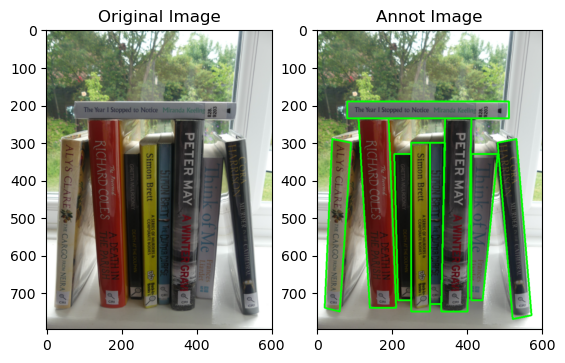

In [2]:
img = read_image("images/bookshelf3.png", max_dim=1024)

polygons = [
    [[80, 190], [510, 190], [510, 235], [80, 235]],
    [[40, 290], [90, 300], [60, 750], [20, 740]],
    [[110, 235], [190, 235], [210, 740], [140, 740]],
    [[205, 330], [250, 330], [250, 720], [215, 720]],
    [[250, 300], [300, 300], [300, 750], [250, 750]],
    [[300, 300], [340, 300], [330, 730], [300, 730]],
    [[340, 235], [410, 235], [400, 750], [330, 750]],
    [[410, 330], [480, 330], [440, 720], [410, 720]],
    [[480, 300], [530, 290], [570, 760], [520, 770]],
]

annot_img = draw_segments(
    img,
    polygons,
)

print(f"Image shape is {img.shape}")

plt.figure(figsize=(8,8))
fig, ax = plt.subplots(1, 2)
ax[0].set_title("Original Image")
ax[0].imshow(img)
ax[1].set_title("Annot Image")
ax[1].imshow(annot_img)
plt.show()

Image shape is (445, 888, 3)


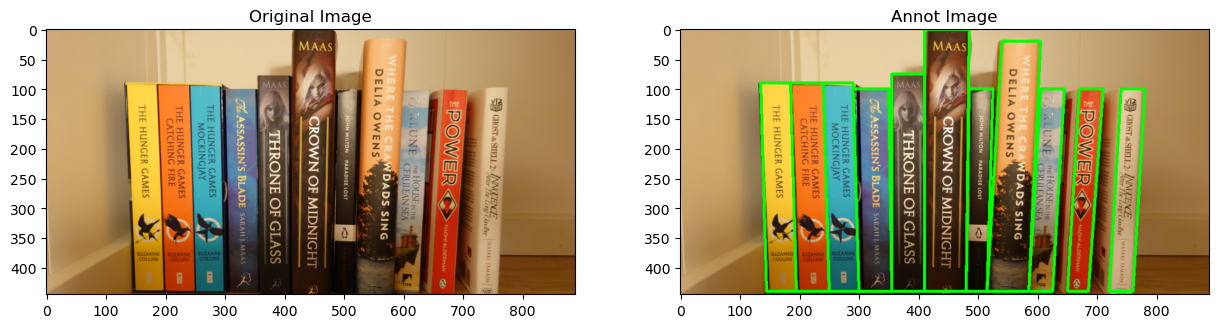

In [3]:
img = read_image("images/bookshelf.png", max_dim=1024)

polygons = [
    [[135, 90], [185, 90], [195, 440], [145, 440]],
    [[185, 90], [240, 90], [250, 440], [195, 440]],
    [[240, 90], [290, 90], [300, 440], [250, 440]],
    [[290, 100], [350, 100], [355, 440], [300, 440]],
    [[355, 75], [410, 75], [410, 440], [355, 440]],
    [[410, 0], [485, 0], [480, 440], [410, 440]],
    [[485, 100], [525, 100], [515, 440], [480, 440]],
    [[540, 20], [605, 20], [585, 440], [515, 440]],
    [[605, 100], [645, 100], [625, 440], [585, 440]],
    [[670, 100], [710, 100], [685, 440], [650, 440]],
    [[740, 100], [780, 100], [760, 440], [720, 440]],
]

annot_img = draw_segments(
    img,
    polygons,
)

print(f"Image shape is {img.shape}")

fig, ax = plt.subplots(1, 2, figsize=(15,15))
ax[0].set_title("Original Image")
ax[0].imshow(img)
ax[1].set_title("Annot Image")
ax[1].imshow(annot_img)
plt.show()

Image shape is (675, 1024, 3)


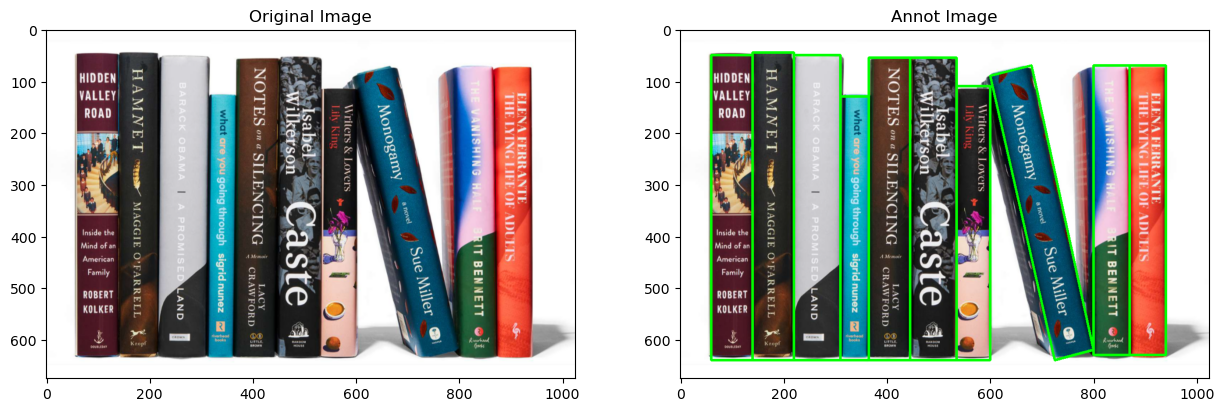

In [4]:
img = read_image("images/bookshelf8.png", max_dim=1024)

polygons = [
    [[60, 50], [140, 50], [140, 640], [60, 640]],
    [[140, 45], [220, 45], [220, 640], [140, 640]],
    [[220, 50], [310, 50], [310, 640], [220, 640]],
    [[310, 130], [365, 130], [365, 640], [310, 640]],
    [[365, 55], [445, 55], [445, 640], [365, 640]],
    [[445, 55], [535, 55], [535, 640], [445, 640]],
    [[535, 110], [600, 110], [600, 640], [535, 640]],
    [[600, 90], [680, 70], [800, 620], [725, 640]],
    [[800, 70], [870, 70], [870, 630], [800, 630]],
    [[870, 70], [940, 70], [940, 630], [870, 630]],
]

annot_img = draw_segments(
    img,
    polygons,
)

print(f"Image shape is {img.shape}")

fig, ax = plt.subplots(1, 2, figsize=(15,15))
ax[0].set_title("Original Image")
ax[0].imshow(img)
ax[1].set_title("Annot Image")
ax[1].imshow(annot_img)
plt.show()

In [5]:
# save_ground_truth(img, polygons)

## Evaluation

In [1]:
from eval.segmentation import variation_of_information, mutual_information, evaluate_segmentation, compare_segmentations
from app.services.image_processing import segment_hough, segment_rect, visualize_masks

Depth 0 | Split 1: score=0.408, direction=horizontal, pos=190, child ratios=0.24, 0.76
Depth 1 | Split 2: score=1.724, direction=vertical, pos=510, child ratios=0.85, 0.15
Depth 1 | Split 3: score=0.494, direction=horizontal, pos=240, child ratios=0.08, 0.92
Depth 2 | Split 4: score=0.381, direction=vertical, pos=30, child ratios=0.05, 0.95
Depth 3 | Split 5: score=0.306, direction=horizontal, pos=295, child ratios=0.10, 0.90
Depth 4 | Split 6: score=0.333, direction=vertical, pos=545, child ratios=0.90, 0.10
Depth 5 | Split 7: score=0.271, direction=vertical, pos=505, child ratios=0.92, 0.08
Depth 6 | Split 8: score=0.275, direction=vertical, pos=455, child ratios=0.89, 0.11
Depth 7 | Split 9: score=0.283, direction=vertical, pos=395, child ratios=0.86, 0.14
Depth 8 | Split 10: score=0.504, direction=vertical, pos=295, child ratios=0.73, 0.27
Depth 9 | Split 11: score=0.554, direction=horizontal, pos=330, child ratios=0.07, 0.93

Total segments: 11
Depth 0 | Split 1: score=0.348, chil

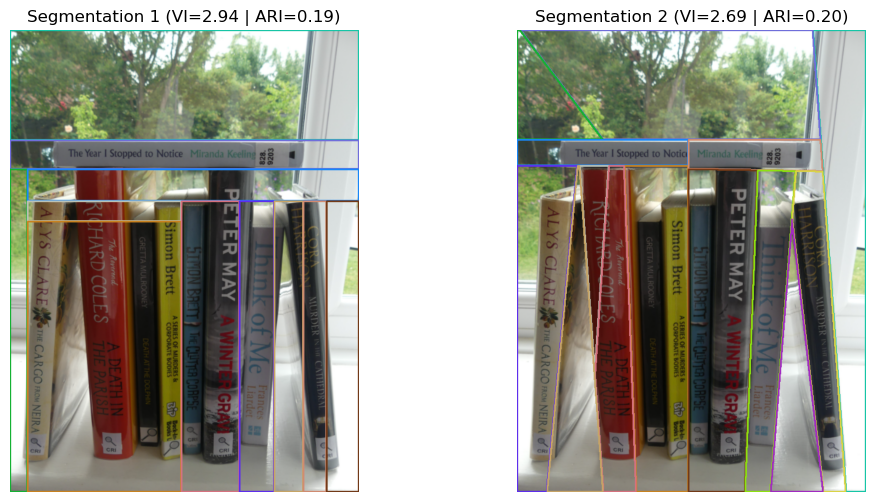

In [6]:
def segment_rect_configured(img):
    masks = segment_rect(img, verbose=True)
    return masks

def segment_hough_configured(img):
    masks = segment_hough(img, verbose=True, min_score=0.05, ignore_min_score=5, blur_ksize=(7,7))
    return masks

compare_segmentations("images/eval", segmentation_function1=segment_rect_configured, segmentation_function2=segment_hough_configured, image_index=0)

In [ ]:
def segment_rect_configured(img):
    masks = segment_rect(img, verbose=False)
    return masks

eval1 = evaluate_segmentation("images/eval", segment_rect_configured)


Total segments: 11
test_img_0.png: VI = 2.9426 | ARI = 0.1940

Total segments: 11
test_img_1.png: VI = 2.6045 | ARI = 0.2764

Total segments: 11
test_img_2.png: VI = 2.1570 | ARI = 0.3043

--------------------
Final Results
--------------------
VI:  2.5680 ± 0.3941
ARI: 0.2582 ± 0.0574


In [ ]:
def segment_hough_configured(img):
    masks = segment_hough(img, verbose=False, max_depth=10, min_score=0.05, ignore_min_score=5, blur_ksize=(7,7))
    return masks

eval2 = evaluate_segmentation("images/eval", segment_hough_configured)

test_img_0.png: VI = 3.1088 | ARI = 0.1036
test_img_1.png: VI = 2.5478 | ARI = 0.2884
test_img_2.png: VI = 2.4535 | ARI = 0.2870

--------------------
Final Results
--------------------
VI:  2.7034 ± 0.3543
ARI: 0.2263 ± 0.1063
